# 13. Контролируемый канал пониженной прочности

Проверка реакции DBM на заранее заданный дефект материала:
сравнение формы дерева, продвижения фронта и вероятности пробоя
при различных коэффициентах ослабления канала.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dataclasses import replace
from src.config import SimulationConfig, WeakPathConfig
from src.defects import build_weak_path
from src.config import SimulationConfig
from src.defects import make_segment_mask
from src.morphology import (
    compute_basic_morphology,
    depth_trajectory,
)
from src.simulator import run_simulation

Размер: (101, 101)
Тип: bool
Число клеток внутри: 463


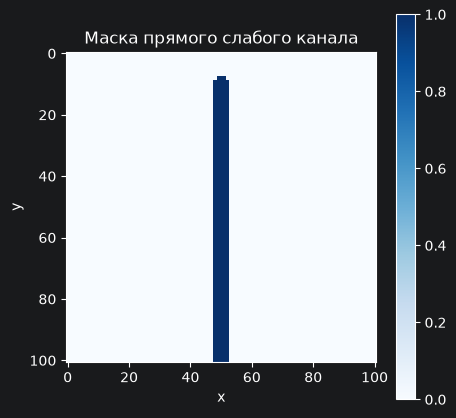

In [2]:
config = SimulationConfig(
    nx=101,
    ny=101,
)

mask = make_segment_mask(
    config=config,
    start=(0.5, 0.1),
    end=(0.5, 1.0),
    width=0.05,
)

print("Размер:", mask.shape)
print("Тип:", mask.dtype)
print("Число клеток внутри:", mask.sum())

assert mask[50, 50]
assert not mask[50, 10]

plt.figure(figsize=(5, 5))

plt.imshow(
    mask,
    origin="upper",
    cmap="Blues",
)

plt.title("Маска прямого слабого канала")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

plt.show()

Уникальные коэффициенты:
[0.6 1. ]
Внутри канала:
[0.6]
Вне канала:
[1.]


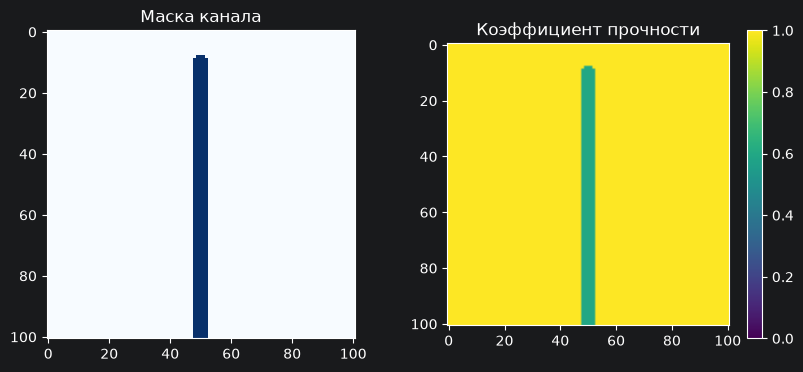

In [3]:
config = SimulationConfig(
    nx=101,
    ny=101,
    weak_path=WeakPathConfig(
        kind="straight",
        width=0.05,
        factor=0.6,
        start=(0.5, 0.1),
        end=(0.5, 1.0),
    ),
)

factor_map, mask = build_weak_path(config)

print("Уникальные коэффициенты:")
print(np.unique(factor_map))

print("Внутри канала:")
print(np.unique(factor_map[mask]))

print("Вне канала:")
print(np.unique(factor_map[~mask]))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

axes[0].imshow(
    mask,
    origin="upper",
    cmap="Blues",
)

axes[0].set_title("Маска канала")

image = axes[1].imshow(
    factor_map,
    origin="upper",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

axes[1].set_title("Коэффициент прочности")

fig.colorbar(
    image,
    ax=axes[1],
)

plt.show()

In [4]:
config = SimulationConfig(
    nx=128,
    ny=128,

    mean_breakdown_field=0.5,
    eta=1.5,

    correlation_length=5,
    weibull_shape=5.0,

    disorder_seed=7,
    random_seed=11,

    max_growth_steps=500,

    weak_path=WeakPathConfig(
        kind="straight",
        width=0.08,
        factor=0.5,
        start=(0.5, 0.1),
        end=(0.5, 1.0),
    ),
)

field, history, breakdown = run_simulation(
    config
)

factor_map, weak_path_mask = build_weak_path(
    config
)

print("Количество шагов:", len(history))
print("Полный пробой:", breakdown)

Количество шагов: 500
Полный пробой: False


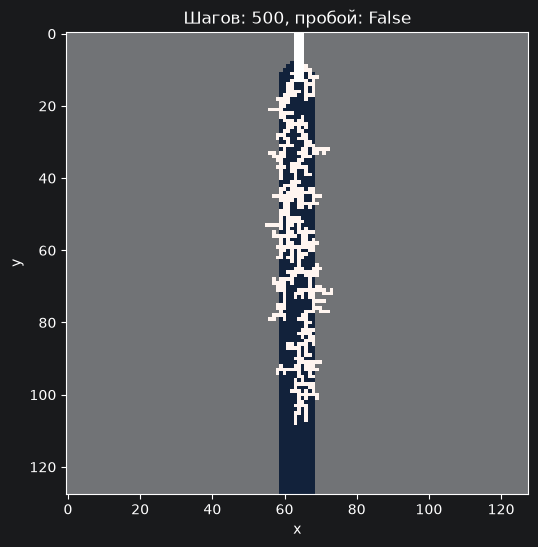

In [5]:
plt.figure(figsize=(6, 6))

plt.imshow(
    weak_path_mask,
    origin="upper",
    cmap="Blues",
    alpha=0.4,
)

tree_layer = np.ma.masked_where(
    ~field.channel,
    field.channel,
)

plt.imshow(
    tree_layer,
    origin="upper",
    cmap="Reds",
)

needle_layer = np.ma.masked_where(
    ~field.needle,
    field.needle,
)

plt.imshow(
    needle_layer,
    origin="upper",
    cmap="Greys",
)

plt.title(
    f"Шагов: {len(history)}, пробой: {breakdown}"
)

plt.xlabel("x")
plt.ylabel("y")

plt.show()

In [6]:



metrics = compute_basic_morphology(
    channel=field.channel,
    history=history,
    weak_path_mask=weak_path_mask,
)

for name, value in metrics.items():
    print(f"{name}: {value}")

steps: 500
area: 500
max_y: 108
height_fraction: 0.8503937007874016
x_std_pixels: 3.5973740422702782
x_std_fraction: 0.028325779860395892
horizontal_span_pixels: 18
horizontal_span_fraction: 0.14173228346456693
weak_path_cells: 426
weak_path_fraction: 0.852
mean_vertical_speed: 0.1963927855711423


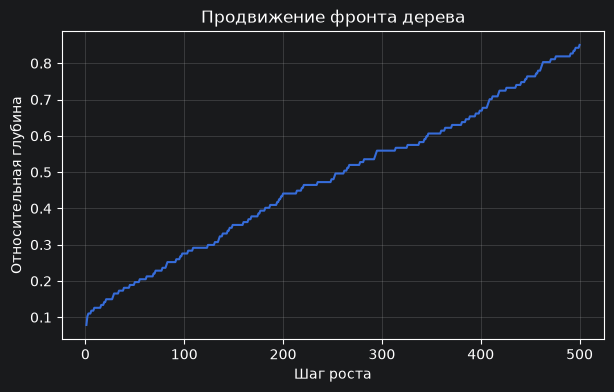

In [7]:
trajectory = depth_trajectory(
    history
)

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(trajectory) + 1),
    trajectory / (config.ny - 1),
)

plt.xlabel("Шаг роста")
plt.ylabel("Относительная глубина")
plt.title("Продвижение фронта дерева")

plt.grid(alpha=0.3)

plt.show()

In [8]:
control_config = replace(
    config,
    weak_path=replace(
        config.weak_path,
        factor=1.0,
    ),
)

weak_config = replace(
    config,
    weak_path=replace(
        config.weak_path,
        factor=0.5,
    ),
)

In [12]:
field_control, history_control, breakdown_control = (
    run_simulation(control_config)
)

field_weak, history_weak, breakdown_weak = (
    run_simulation(weak_config)
)

_, control_mask = build_weak_path(
    control_config
)

_, weak_mask = build_weak_path(
    weak_config
)

control_metrics = compute_basic_morphology(
    channel=field_control.channel,
    history=history_control,
    weak_path_mask=control_mask,
)

weak_metrics = compute_basic_morphology(
    channel=field_weak.channel,
    history=history_weak,
    weak_path_mask=weak_mask,
)

In [13]:
comparison = pd.DataFrame(
    [
        {
            "factor": 1.0,
            "breakdown": breakdown_control,
            **control_metrics,
        },
        {
            "factor": 0.5,
            "breakdown": breakdown_weak,
            **weak_metrics,
        },
    ]
)

comparison[
    [
        "factor",
        "steps",
        "breakdown",
        "height_fraction",
        "weak_path_fraction",
        "x_std_fraction",
        "horizontal_span_fraction",
        "mean_vertical_speed",
    ]
]

,factor,steps,breakdown,height_fraction,weak_path_fraction,x_std_fraction,horizontal_span_fraction,mean_vertical_speed
0,1.0,500,False,0.724409,0.424,0.067518,0.307087,0.164329
1,0.5,500,False,0.850394,0.852,0.028326,0.141732,0.196393


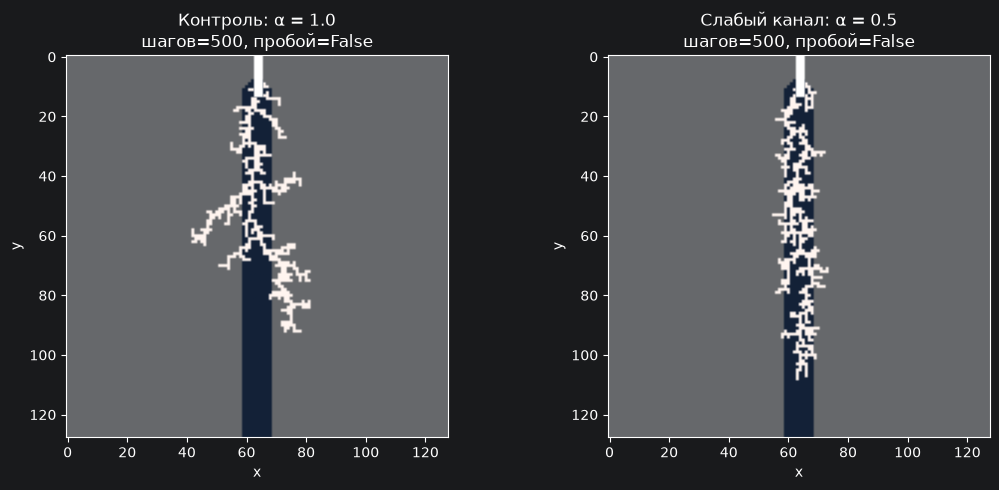

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
)


cases = [
    (
        field_control,
        control_mask,
        history_control,
        breakdown_control,
        "Контроль: α = 1.0",
    ),
    (
        field_weak,
        weak_mask,
        history_weak,
        breakdown_weak,
        "Слабый канал: α = 0.5",
    ),
]


for axis, (
    current_field,
    current_mask,
    current_history,
    current_breakdown,
    title,
) in zip(axes, cases):

    axis.imshow(
        current_mask,
        origin="upper",
        cmap="Blues",
        alpha=0.35,
    )

    tree_layer = np.ma.masked_where(
        ~current_field.channel,
        current_field.channel,
    )

    axis.imshow(
        tree_layer,
        origin="upper",
        cmap="Reds",
    )

    needle_layer = np.ma.masked_where(
        ~current_field.needle,
        current_field.needle,
    )

    axis.imshow(
        needle_layer,
        origin="upper",
        cmap="Greys",
    )

    axis.set_title(
        f"{title}\n"
        f"шагов={len(current_history)}, "
        f"пробой={current_breakdown}"
    )

    axis.set_xlabel("x")
    axis.set_ylabel("y")


plt.tight_layout()
plt.show()

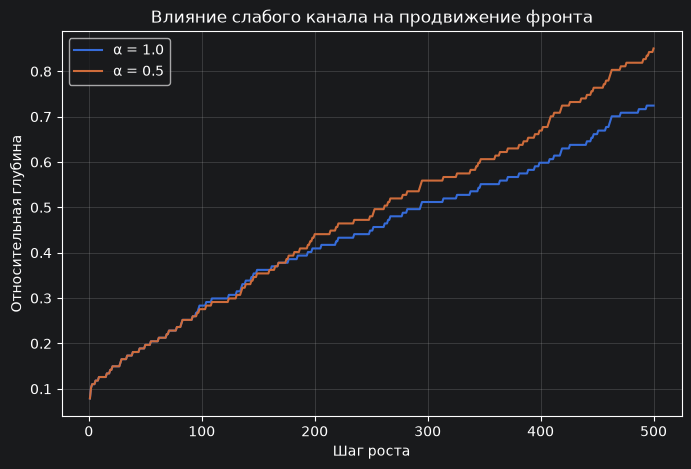

In [15]:
control_trajectory = depth_trajectory(
    history_control
)

weak_trajectory = depth_trajectory(
    history_weak
)


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(control_trajectory) + 1),
    control_trajectory / (config.ny - 1),
    label="α = 1.0",
)

plt.plot(
    range(1, len(weak_trajectory) + 1),
    weak_trajectory / (config.ny - 1),
    label="α = 0.5",
)

plt.xlabel("Шаг роста")
plt.ylabel("Относительная глубина")
plt.title("Влияние слабого канала на продвижение фронта")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [16]:
from src.controlled_experiments import (
    run_controlled_case,
)


test_record = run_controlled_case(
    base_config=config,
    factor=0.5,
    disorder_seed=7,
    random_seed=11,
)

test_record

{'factor': 0.5,
 'disorder_seed': 7,
 'random_seed': 11,
 'status': 'max_steps',
 'started': True,
 'breakdown': False,
 'captured': True,
 'steps': 500,
 'area': np.int64(500),
 'max_y': np.int64(108),
 'height_fraction': np.float64(0.8503937007874016),
 'x_std_pixels': np.float64(3.5973740422702782),
 'x_std_fraction': np.float64(0.028325779860395892),
 'horizontal_span_pixels': np.int64(18),
 'horizontal_span_fraction': np.float64(0.14173228346456693),
 'weak_path_cells': 426,
 'weak_path_fraction': np.float64(0.852),
 'mean_vertical_speed': 0.1963927855711423}

In [17]:
alphas = [
    1.0,
    0.8,
    0.6,
    0.4,
]

disorder_seeds = [
    0,
    1,
]

random_seeds = [
    0,
    1,
    2,
]

records = []


for alpha in alphas:

    for disorder_seed in disorder_seeds:

        for random_seed in random_seeds:

            record = run_controlled_case(
                base_config=config,
                factor=alpha,
                disorder_seed=disorder_seed,
                random_seed=random_seed,
            )

            records.append(record)


results = pd.DataFrame(
    records
)

results.head(10)

,factor,disorder_seed,random_seed,status,started,breakdown,captured,steps,area,max_y,height_fraction,x_std_pixels,x_std_fraction,horizontal_span_pixels,horizontal_span_fraction,weak_path_cells,weak_path_fraction,mean_vertical_speed
0,1.0,0,0,max_steps,True,False,False,500,500,105,0.826772,6.317784,0.049746,31,0.244094,293,0.586,0.182365
1,1.0,0,1,max_steps,True,False,False,500,500,85,0.669291,13.946414,0.109814,60,0.472441,163,0.326,0.142285
2,1.0,0,2,max_steps,True,False,False,500,500,92,0.724409,9.788967,0.077078,44,0.346457,211,0.422,0.158317
3,1.0,1,0,max_steps,True,False,False,500,500,107,0.842520,9.040287,0.071183,41,0.322835,217,0.434,0.186373
4,1.0,1,1,max_steps,True,False,False,500,500,85,0.669291,11.259842,0.088660,47,0.370079,97,0.194,0.144289
5,1.0,1,2,max_steps,True,False,False,500,500,96,0.755906,8.281154,0.065206,40,0.314961,86,0.172,0.168337
6,0.8,0,0,max_steps,True,False,False,500,500,117,0.921260,6.313763,0.049715,33,0.259843,278,0.556,0.206413
7,0.8,0,1,max_steps,True,False,False,500,500,94,0.740157,8.297919,0.065338,48,0.377953,285,0.570,0.160321
8,0.8,0,2,max_steps,True,False,False,500,500,94,0.740157,6.518384,0.051326,31,0.244094,272,0.544,0.162325
9,0.8,1,0,max_steps,True,False,False,500,500,97,0.763780,11.661162,0.091820,53,0.417323,88,0.176,0.166333


In [18]:
summary = (
    results
    .groupby(
        "factor",
        as_index=False,
    )
    .agg(
        n_runs=(
            "factor",
            "size",
        ),

        n_started=(
            "started",
            "sum",
        ),

        n_breakdown=(
            "breakdown",
            "sum",
        ),

        n_captured=(
            "captured",
            "sum",
        ),

        p_start=(
            "started",
            "mean",
        ),

        p_breakdown=(
            "breakdown",
            "mean",
        ),

        p_capture=(
            "captured",
            "mean",
        ),

        mean_height=(
            "height_fraction",
            "mean",
        ),

        std_height=(
            "height_fraction",
            "std",
        ),

        mean_path_fraction=(
            "weak_path_fraction",
            "mean",
        ),

        std_path_fraction=(
            "weak_path_fraction",
            "std",
        ),

        mean_x_std=(
            "x_std_fraction",
            "mean",
        ),

        std_x_std=(
            "x_std_fraction",
            "std",
        ),

        mean_horizontal_span=(
            "horizontal_span_fraction",
            "mean",
        ),

        mean_vertical_speed=(
            "mean_vertical_speed",
            "mean",
        ),
    )
    .sort_values(
        "factor",
        ascending=False,
    )
    .reset_index(
        drop=True,
    )
)

summary

,factor,n_runs,n_started,n_breakdown,n_captured,p_start,p_breakdown,p_capture,mean_height,std_height,mean_path_fraction,std_path_fraction,mean_x_std,std_x_std,mean_horizontal_span,mean_vertical_speed
0,1.0,6,6,0,0,1.0,0.000000,0.0,0.748031,0.075031,0.355667,0.157695,0.076948,0.020632,0.345144,0.163661
1,0.8,6,6,0,0,1.0,0.000000,0.0,0.799213,0.078227,0.508000,0.174085,0.062516,0.019643,0.316273,0.176687
2,0.6,6,6,0,6,1.0,0.000000,1.0,0.897638,0.052703,0.782000,0.049218,0.035846,0.006856,0.203412,0.201737
3,0.4,6,6,2,6,1.0,0.333333,1.0,0.958005,0.036820,0.886604,0.037447,0.027065,0.002604,0.127297,0.222067


In [19]:
status_table = pd.crosstab(
    index=results["factor"],
    columns=results["status"],
)

status_table

status,breakdown,max_steps
factor,,
0.4,2,4
0.6,0,6
0.8,0,6
1.0,0,6


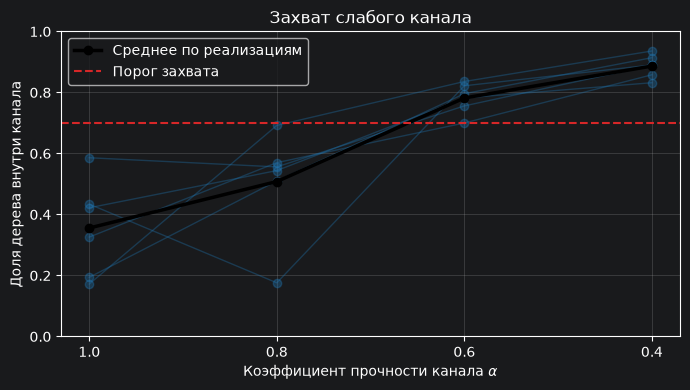

In [20]:
paired_path_fraction = results.pivot(
    index=["disorder_seed", "random_seed"],
    columns="factor",
    values="weak_path_fraction",
).sort_index(axis=1, ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))

for seed_pair, row in paired_path_fraction.iterrows():
    ax.plot(
        row.index,
        row.values,
        marker="o",
        color="tab:blue",
        alpha=0.35,
        linewidth=1,
    )

mean_path_fraction = paired_path_fraction.mean(axis=0)

ax.plot(
    mean_path_fraction.index,
    mean_path_fraction.values,
    marker="o",
    color="black",
    linewidth=2.5,
    label="Среднее по реализациям",
)

ax.axhline(
    0.7,
    color="tab:red",
    linestyle="--",
    label="Порог захвата",
)

ax.set_xlabel(r"Коэффициент прочности канала $\alpha$")
ax.set_ylabel("Доля дерева внутри канала")
ax.set_title("Захват слабого канала")
ax.set_xticks(paired_path_fraction.columns)
ax.set_ylim(0, 1)
ax.invert_xaxis()
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [21]:
from joblib import Parallel, delayed

alphas_large = [
    1.0,
    0.9,
    0.8,
    0.75,
    0.7,
    0.65,
    0.6,
    0.5,
    0.4,
]

seed_pairs = [
    (seed, 10_000 + seed)
    for seed in range(30)
]

tasks = [
    (alpha, disorder_seed, random_seed)
    for alpha in alphas_large
    for disorder_seed, random_seed in seed_pairs
]

records_large = Parallel(
    n_jobs=-1,
    verbose=10,
)(
    delayed(run_controlled_case)(
        base_config=config,
        factor=alpha,
        disorder_seed=disorder_seed,
        random_seed=random_seed,
        capture_threshold=0.7,
    )
    for alpha, disorder_seed, random_seed in tasks
)

results_large = pd.DataFrame(records_large)

results_large.to_csv(
    "controlled_weak_path_large.csv",
    index=False,
)

print("Размер таблицы:", results_large.shape)
print("\nЧисло запусков для каждого alpha:")
print(results_large.groupby("factor").size())

print("\nСтатусы завершения:")
display(
    pd.crosstab(
        index=results_large["factor"],
        columns=results_large["status"],
    )
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   20.4s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   25.5s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:   32.9s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:   39.4s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:   47.1s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:   54.8s
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 197 tasks      | elapsed:  

Размер таблицы: (270, 18)

Число запусков для каждого alpha:
factor
0.40    30
0.50    30
0.60    30
0.65    30
0.70    30
0.75    30
0.80    30
0.90    30
1.00    30
dtype: int64

Статусы завершения:


[Parallel(n_jobs=-1)]: Done 270 out of 270 | elapsed:  2.4min finished


status,breakdown,max_steps
factor,,
0.40,9,21
0.50,3,27
0.60,1,29
0.65,2,28
0.70,1,29
0.75,0,30
0.80,0,30
0.90,0,30
1.00,0,30


,factor,n,mean,median,std,ci_low,ci_high,p_capture,p_breakdown
0,1.00,30,0.346,0.344,0.149,0.293,0.397,0.000,0.000
1,0.90,30,0.427,0.420,0.136,0.379,0.474,0.000,0.000
2,0.80,30,0.526,0.558,0.145,0.473,0.574,0.033,0.000
3,0.75,30,0.607,0.629,0.130,0.559,0.650,0.267,0.000
4,0.70,30,0.664,0.683,0.111,0.624,0.703,0.467,0.033
5,0.65,30,0.730,0.751,0.068,0.706,0.754,0.700,0.067
6,0.60,30,0.742,0.759,0.067,0.718,0.764,0.767,0.033
7,0.50,30,0.832,0.828,0.047,0.815,0.849,1.000,0.100
8,0.40,30,0.880,0.877,0.030,0.869,0.891,1.000,0.300


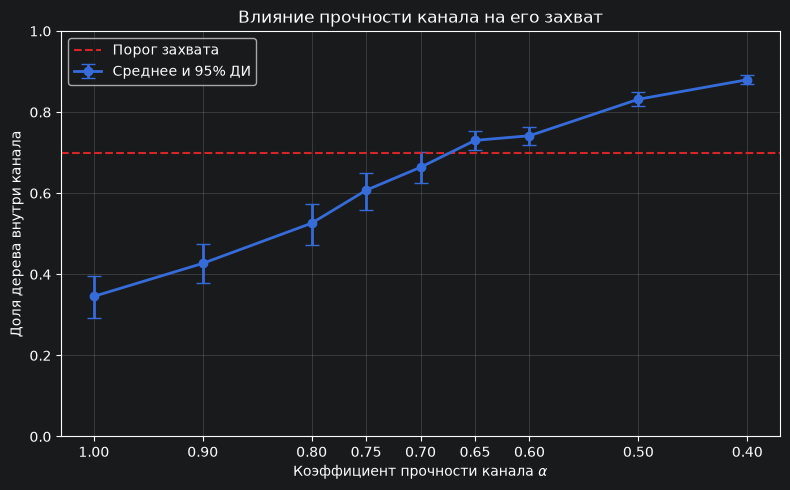

In [22]:
rng = np.random.default_rng(20260923)
n_bootstrap = 5000

summary_rows = []

for factor, group in results_large.groupby("factor"):
    values = group["weak_path_fraction"].dropna().to_numpy()

    bootstrap_indices = rng.integers(
        low=0,
        high=len(values),
        size=(n_bootstrap, len(values)),
    )

    bootstrap_means = values[bootstrap_indices].mean(axis=1)

    summary_rows.append(
        {
            "factor": factor,
            "n": len(values),
            "mean": values.mean(),
            "median": np.median(values),
            "std": values.std(ddof=1),
            "ci_low": np.percentile(bootstrap_means, 2.5),
            "ci_high": np.percentile(bootstrap_means, 97.5),
            "p_capture": group["captured"].mean(),
            "p_breakdown": group["breakdown"].mean(),
        }
    )

path_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("factor", ascending=False)
    .reset_index(drop=True)
)

display(path_summary.round(3))

lower_error = path_summary["mean"] - path_summary["ci_low"]
upper_error = path_summary["ci_high"] - path_summary["mean"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    path_summary["factor"],
    path_summary["mean"],
    yerr=[lower_error, upper_error],
    marker="o",
    linewidth=2,
    capsize=5,
    label="Среднее и 95% ДИ",
)

ax.axhline(
    0.7,
    color="tab:red",
    linestyle="--",
    label="Порог захвата",
)

ax.set_xlabel(r"Коэффициент прочности канала $\alpha$")
ax.set_ylabel("Доля дерева внутри канала")
ax.set_title("Влияние прочности канала на его захват")
ax.set_xticks(alphas_large)
ax.set_ylim(0, 1)
ax.invert_xaxis()
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import friedmanchisquare, wilcoxon

paired_path = (
    results_large.pivot(
        index=["disorder_seed", "random_seed"],
        columns="factor",
        values="weak_path_fraction",
    )
    .reindex(columns=alphas_large)
    .dropna()
)

friedman_result = friedmanchisquare(
    *[
        paired_path[factor].to_numpy()
        for factor in alphas_large
    ]
)

n_pairs = paired_path.shape[0]
n_factors = paired_path.shape[1]

kendalls_w = (
    friedman_result.statistic
    / (n_pairs * (n_factors - 1))
)

print(f"Число полных пар: {n_pairs}")
print(f"Статистика Фридмана: {friedman_result.statistic:.3f}")
print(f"p-value Фридмана: {friedman_result.pvalue:.3e}")
print(f"Коэффициент Кендалла W: {kendalls_w:.3f}")


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)

    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)

    number_of_tests = len(p_values)
    running_maximum = 0.0

    for rank, original_index in enumerate(order):
        corrected_value = (
            number_of_tests - rank
        ) * p_values[original_index]

        running_maximum = max(
            running_maximum,
            corrected_value,
        )

        adjusted[original_index] = min(
            running_maximum,
            1.0,
        )

    return adjusted


control_factor = 1.0
pairwise_rows = []

for factor in alphas_large:
    if factor == control_factor:
        continue

    control_values = paired_path[control_factor]
    factor_values = paired_path[factor]

    differences = factor_values - control_values

    wilcoxon_result = wilcoxon(
        factor_values,
        control_values,
        alternative="two-sided",
    )

    pairwise_rows.append(
        {
            "factor": factor,
            "mean_difference": differences.mean(),
            "median_difference": differences.median(),
            "wilcoxon_statistic": wilcoxon_result.statistic,
            "p_raw": wilcoxon_result.pvalue,
        }
    )

pairwise_results = pd.DataFrame(pairwise_rows)

pairwise_results["p_holm"] = holm_adjust(
    pairwise_results["p_raw"].to_numpy()
)

pairwise_results["significant_0.05"] = (
    pairwise_results["p_holm"] < 0.05
)

display(
    pairwise_results.style.format(
        {
            "factor": "{:.2f}",
            "mean_difference": "{:.3f}",
            "median_difference": "{:.3f}",
            "wilcoxon_statistic": "{:.1f}",
            "p_raw": "{:.3e}",
            "p_holm": "{:.3e}",
        }
    )
)

Число полных пар: 30
Статистика Фридмана: 209.580
p-value Фридмана: 6.102e-41
Коэффициент Кендалла W: 0.873


,factor,mean_difference,median_difference,wilcoxon_statistic,p_raw,p_holm,significant_0.05
0,0.90,0.081,0.097,87.0,2.765e-03,2.765e-03,True
1,0.80,0.180,0.143,34.0,4.447e-05,8.895e-05,True
2,0.75,0.262,0.254,4.0,1.304e-08,1.043e-07,True
3,0.70,0.318,0.320,1.0,1.920e-06,1.213e-05,True
4,0.65,0.385,0.394,1.0,1.916e-06,1.213e-05,True
5,0.60,0.396,0.416,0.0,1.733e-06,1.213e-05,True
6,0.50,0.486,0.484,0.0,1.733e-06,1.213e-05,True
7,0.40,0.534,0.532,0.0,1.732e-06,1.213e-05,True


beta_0 = -6.700
beta_1 = 21.289
Критическое alpha_50 = 0.685


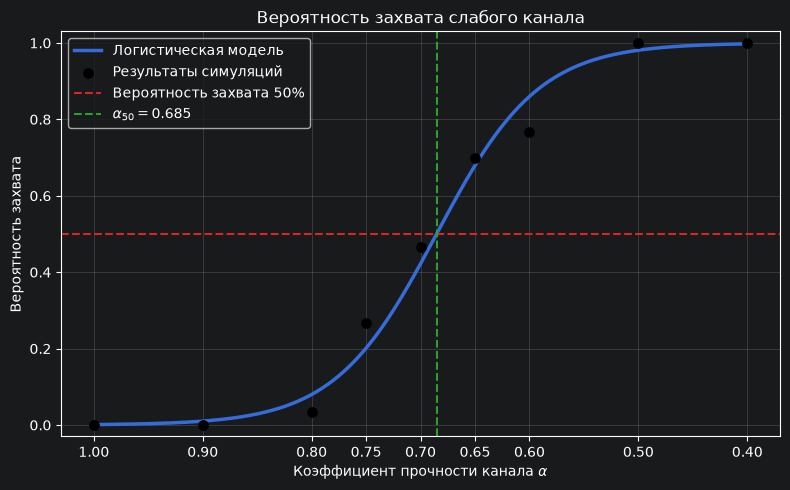

In [24]:
from scipy.optimize import minimize
from scipy.special import expit

def fit_capture_logistic(factors, captured):
    factors = np.asarray(factors, dtype=float)
    captured = np.asarray(captured, dtype=float)

    weakness = 1.0 - factors

    def negative_log_likelihood(beta):
        logits = beta[0] + beta[1] * weakness

        return np.sum(
            np.logaddexp(0.0, logits)
            - captured * logits
        )

    result = minimize(
        negative_log_likelihood,
        x0=np.array([-6.0, 20.0]),
        method="L-BFGS-B",
        bounds=[
            (-100.0, 100.0),
            (1e-6, 100.0),
        ],
    )

    if not result.success:
        raise RuntimeError(result.message)

    return result.x


beta_0, beta_1 = fit_capture_logistic(
    factors=results_large["factor"],
    captured=results_large["captured"],
)

weakness_50 = -beta_0 / beta_1
alpha_50 = 1.0 - weakness_50

print(f"beta_0 = {beta_0:.3f}")
print(f"beta_1 = {beta_1:.3f}")
print(f"Критическое alpha_50 = {alpha_50:.3f}")


factor_grid = np.linspace(
    results_large["factor"].min(),
    results_large["factor"].max(),
    400,
)

probability_grid = expit(
    beta_0 + beta_1 * (1.0 - factor_grid)
)

empirical_capture = (
    results_large
    .groupby("factor", as_index=False)["captured"]
    .mean()
    .sort_values("factor", ascending=False)
)


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    factor_grid,
    probability_grid,
    linewidth=2.5,
    label="Логистическая модель",
)

ax.scatter(
    empirical_capture["factor"],
    empirical_capture["captured"],
    color="black",
    s=45,
    zorder=3,
    label="Результаты симуляций",
)

ax.axhline(
    0.5,
    color="tab:red",
    linestyle="--",
    label="Вероятность захвата 50%",
)

ax.axvline(
    alpha_50,
    color="tab:green",
    linestyle="--",
    label=fr"$\alpha_{{50}}={alpha_50:.3f}$",
)

ax.set_xlabel(r"Коэффициент прочности канала $\alpha$")
ax.set_ylabel("Вероятность захвата")
ax.set_title("Вероятность захвата слабого канала")
ax.set_ylim(-0.03, 1.03)
ax.set_xticks(alphas_large)
ax.invert_xaxis()
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Успешных bootstrap-оценок: 2000 из 2000
alpha_50 = 0.685
95% bootstrap ДИ: [0.657, 0.713]


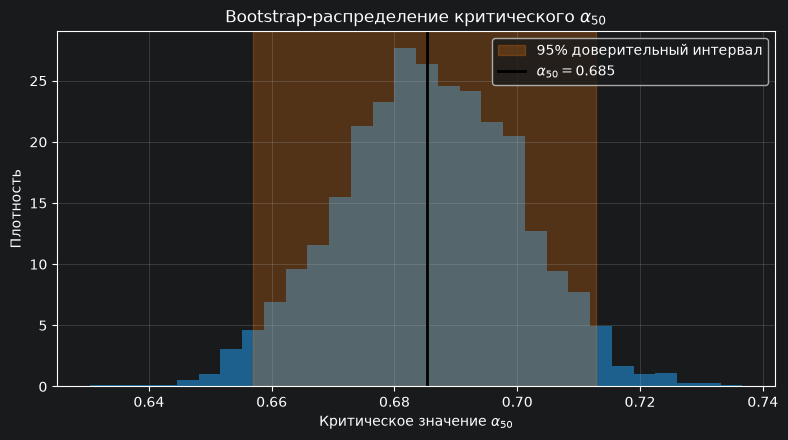

In [25]:
capture_matrix = (
    results_large.pivot(
        index=["disorder_seed", "random_seed"],
        columns="factor",
        values="captured",
    )
    .reindex(columns=alphas_large)
    .astype(int)
)

capture_values = capture_matrix.to_numpy()

number_of_pairs = capture_values.shape[0]
number_of_bootstrap_samples = 2000

bootstrap_factors = np.tile(
    np.asarray(alphas_large, dtype=float),
    number_of_pairs,
)

bootstrap_alpha_50 = np.full(
    number_of_bootstrap_samples,
    np.nan,
)

bootstrap_rng = np.random.default_rng(20260923)

for bootstrap_index in range(number_of_bootstrap_samples):
    sampled_rows = bootstrap_rng.integers(
        low=0,
        high=number_of_pairs,
        size=number_of_pairs,
    )

    sampled_captured = (
        capture_values[sampled_rows]
        .reshape(-1)
    )

    try:
        bootstrap_beta_0, bootstrap_beta_1 = (
            fit_capture_logistic(
                factors=bootstrap_factors,
                captured=sampled_captured,
            )
        )

        bootstrap_alpha_50[bootstrap_index] = (
            1.0
            + bootstrap_beta_0 / bootstrap_beta_1
        )

    except RuntimeError:
        continue

valid_alpha_50 = bootstrap_alpha_50[
    np.isfinite(bootstrap_alpha_50)
]

alpha_50_ci_low = np.percentile(
    valid_alpha_50,
    2.5,
)

alpha_50_ci_high = np.percentile(
    valid_alpha_50,
    97.5,
)

print(
    "Успешных bootstrap-оценок:",
    len(valid_alpha_50),
    "из",
    number_of_bootstrap_samples,
)

print(f"alpha_50 = {alpha_50:.3f}")
print(
    "95% bootstrap ДИ: "
    f"[{alpha_50_ci_low:.3f}, "
    f"{alpha_50_ci_high:.3f}]"
)


fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(
    valid_alpha_50,
    bins=30,
    density=True,
    alpha=0.75,
    color="tab:blue",
)

ax.axvspan(
    alpha_50_ci_low,
    alpha_50_ci_high,
    color="tab:orange",
    alpha=0.25,
    label="95% доверительный интервал",
)

ax.axvline(
    alpha_50,
    color="black",
    linewidth=2,
    label=fr"$\alpha_{{50}}={alpha_50:.3f}$",
)

ax.set_xlabel(r"Критическое значение $\alpha_{50}$")
ax.set_ylabel("Плотность")
ax.set_title(
    r"Bootstrap-распределение критического $\alpha_{50}$"
)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Вывод по эксперименту с прямым слабым каналом

В модель была добавлена контролируемая область пониженной электрической прочности в виде прямого канала. Локальный порог пробоя задавался как

$$
E_{\mathrm{bd}}(x,y)
=
E_{\mathrm{bd}}^{\mathrm{rand}}(x,y)\,m(x,y),
$$

где

$$
m(x,y)=
\begin{cases}
\alpha, & (x,y)\text{ находится внутри канала},\\
1, & (x,y)\text{ находится вне канала}.
\end{cases}
$$

Значение $\alpha=1$ соответствует однородному материалу, а уменьшение $\alpha$ означает ослабление канала. Например, при $\alpha=0.7$ электрическая прочность внутри канала уменьшена на $30\%$.

При одинаковом электрическом поле отношение $E/E_{\mathrm{bd}}$ внутри канала становится больше. Поэтому локальный пробой и дальнейший рост дерева оказываются более вероятными вдоль заданной области пониженной прочности.

Для количественного описания захвата была введена доля дерева внутри канала:

$$
q=
\frac{N_{\mathrm{tree}\cap\mathrm{channel}}}
     {N_{\mathrm{tree}}},
$$

где $N_{\mathrm{tree}}$ — полное число клеток дерева, а $N_{\mathrm{tree}\cap\mathrm{channel}}$ — число клеток дерева внутри слабого канала.

Реализация считалась захваченной каналом при условии

$$
q\geq 0.7.
$$

Было проведено 270 симуляций: исследованы 9 значений $\alpha$, для каждого из которых использовались одинаковые 30 пар случайных сидов. Такая схема позволила проводить парное сравнение: при изменении $\alpha$ случайная структура материала и случайность роста оставались согласованными.

Средняя доля дерева внутри канала увеличилась от

$$
\langle q\rangle=0.346
\quad\text{при}\quad
\alpha=1
$$

до

$$
\langle q\rangle=0.880
\quad\text{при}\quad
\alpha=0.4.
$$

Одновременно стандартное отклонение уменьшилось с $0.149$ до $0.030$. Следовательно, слабый канал не только направляет рост дерева, но и уменьшает влияние случайности: при сильном дефекте траектории становятся более воспроизводимыми.

Для проверки общего влияния $\alpha$ использовался парный непараметрический критерий Фридмана. Был получен результат

$$
\chi_F^2=209.58,
\qquad
p=6.10\cdot10^{-41}.
$$

Так как $p\ll0.05$, гипотеза об одинаковом поведении дерева при разных значениях $\alpha$ отвергается.

Коэффициент согласованности Кендалла составил

$$
W=0.873.
$$

Значение, близкое к единице, показывает очень сильное и согласованное влияние прочности канала на траекторию дерева.

Каждое значение $\alpha$ также сравнивалось с контролем $\alpha=1$ с помощью парного критерия Уилкоксона. Для учёта множественных сравнений применялась поправка Холма. Все исследованные значения, включая $\alpha=0.9$, статистически значимо отличались от контроля:

$$
p_{\mathrm{Holm}}
\leq
2.77\cdot10^{-3}.
$$

При этом статистически обнаружимое отклонение дерева в сторону канала ещё не означает его устойчивого захвата. При $\alpha=0.9$ дерево в среднем чаще растёт вдоль области будущего канала, но условие $q\geq0.7$ практически не выполняется. Переход к устойчивому захвату наблюдается приблизительно между $\alpha=0.70$ и $\alpha=0.65$.

Вероятность захвата была аппроксимирована логистической зависимостью

$$
P_{\mathrm{capture}}(\alpha)
=
\frac{1}
{1+\exp\left[
-\left(
\beta_0+\beta_1(1-\alpha)
\right)
\right]}.
$$

Критическое значение $\alpha_{50}$ определялось условием

$$
P_{\mathrm{capture}}(\alpha_{50})=0.5.
$$

Из логистической модели было получено

$$
\boxed{\alpha_{50}=0.685}.
$$

Для оценки неопределённости использовался кластерный bootstrap с 2000 повторениями. Пересэмплировались целые пары сидов, поэтому зависимость результатов при разных значениях $\alpha$ сохранялась.

Полученный 95%-й доверительный интервал равен

$$
\boxed{
\alpha_{50}\in[0.657;\,0.713]
}.
$$

Таким образом, при заданной геометрии устойчивый захват дерева возникает, когда электрическая прочность канала примерно на $31.5\%$ ниже прочности окружающего материала. С учётом доверительного интервала критическое снижение прочности составляет приблизительно от $28.7\%$ до $34.3\%$.

Модель воспроизводит физически ожидаемый эффект направленного роста электрического дерева вдоль области пониженной прочности. Было получено не только качественное изображение эффекта, но и его количественная характеристика — критический коэффициент $\alpha_{50}$ с доверительным интервалом.

Полученное значение относится к выбранной ширине канала, геометрии задачи, порогу захвата $q=0.7$ и горизонту моделирования 500 шагов, поэтому оно не является универсальной константой материала.